In [1]:
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
import warnings

warnings.filterwarnings('ignore')
import datetime
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="whitegrid")
import datetime
import yfinance as yf

In [2]:
def find_cointegrated_pairs(data):
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

In [3]:
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2026, 1, 1)

tickers = ['AAPL', 'ADBE', 'ORCL', 'EBAY', 'MSFT', 'QCOM', 'HPQ', 'AMD', 'IBM', 'SPY','NVDA','INTC']


df = yf.download(tickers, start, end)['Close']
df.tail()

[*********************100%***********************]  12 of 12 completed


Ticker,AAPL,ADBE,AMD,EBAY,HPQ,IBM,INTC,MSFT,NVDA,ORCL,QCOM,SPY
Date,,,,,,,,,,,,
2025-12-24,273.066711,352.980011,215.039993,83.830132,22.299377,298.479675,36.160000,484.943420,188.169678,195.603302,172.079483,685.029480
2025-12-26,272.657837,353.799988,214.990005,84.434586,22.395662,298.999084,36.200001,484.635406,190.085205,196.098526,172.118866,684.959961
2025-12-29,273.016876,353.160004,215.610001,86.941551,21.885357,299.636108,36.680000,484.029236,187.780594,193.513458,170.760101,682.519043
2025-12-30,272.338684,352.510010,215.339996,86.307381,22.049040,296.019775,37.299999,484.406860,187.102173,195.325974,170.976730,681.685608
2025-12-31,271.122009,349.989990,214.160004,86.307381,21.452080,290.296387,36.900002,480.571167,186.064621,193.047943,168.416748,676.635010


[('AAPL', 'AMD'), ('AAPL', 'MSFT'), ('AAPL', 'QCOM'), ('AMD', 'MSFT'), ('AMD', 'ORCL'), ('AMD', 'QCOM'), ('AMD', 'SPY'), ('IBM', 'NVDA'), ('IBM', 'ORCL'), ('MSFT', 'QCOM'), ('ORCL', 'SPY')]


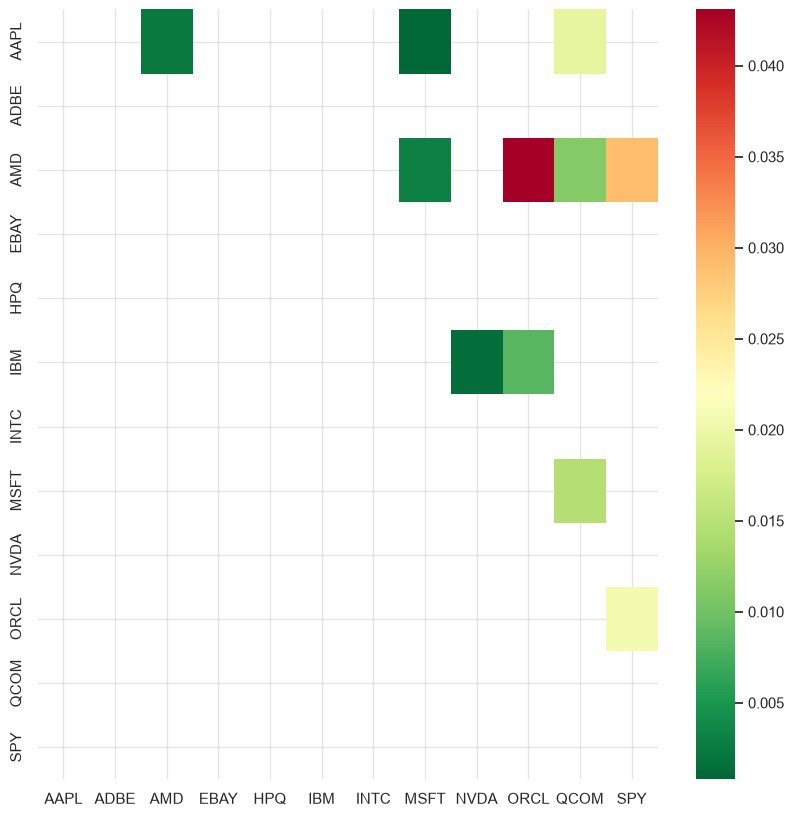

In [4]:
scores, pvalues, pairs = find_cointegrated_pairs(df)
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(pvalues, xticklabels=df.columns, yticklabels=df.columns, cmap='RdYlGn_r'
                , mask = (pvalues >= 0.05)
                )
print(pairs)

In [5]:
ticker_1=['AAPL','AAPL','AMD','IBM','IBM','AMD']
ticker_2=['AMD','MSFT','MSFT','NVDA','ORCL','QCOM']

for i in range(0,len(ticker_1)):
    score, pvalue, _ = coint(df[ticker_1[i]], df[ticker_2[i]])
    print(f"p-value of {ticker_1[i]} and {ticker_2[i]} : {pvalue}")

p-value of AAPL and AMD : 0.0023297865100042757
p-value of AAPL and MSFT : 0.0007889952966893255
p-value of AMD and MSFT : 0.003010487976086174
p-value of IBM and NVDA : 0.0012885446943053504
p-value of IBM and ORCL : 0.00846887936436519
p-value of AMD and QCOM : 0.01126091801186742


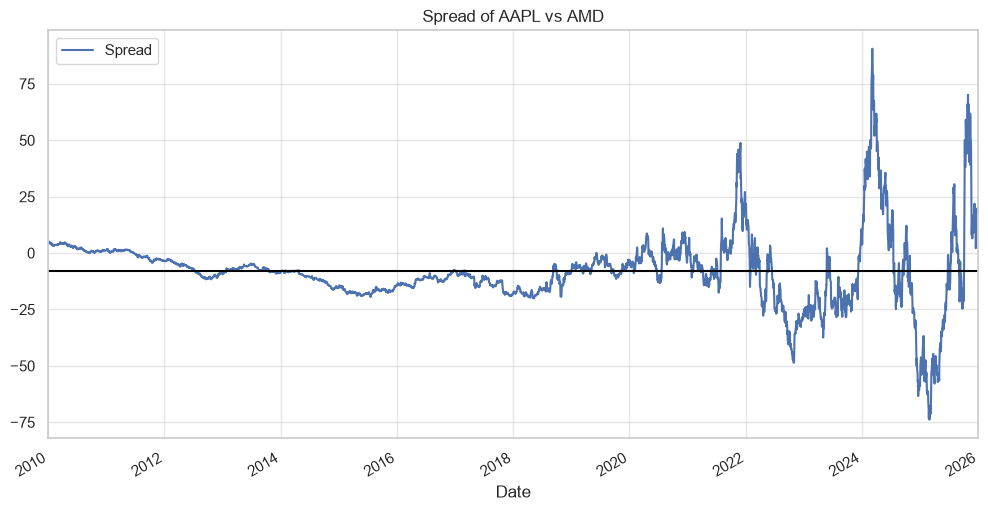

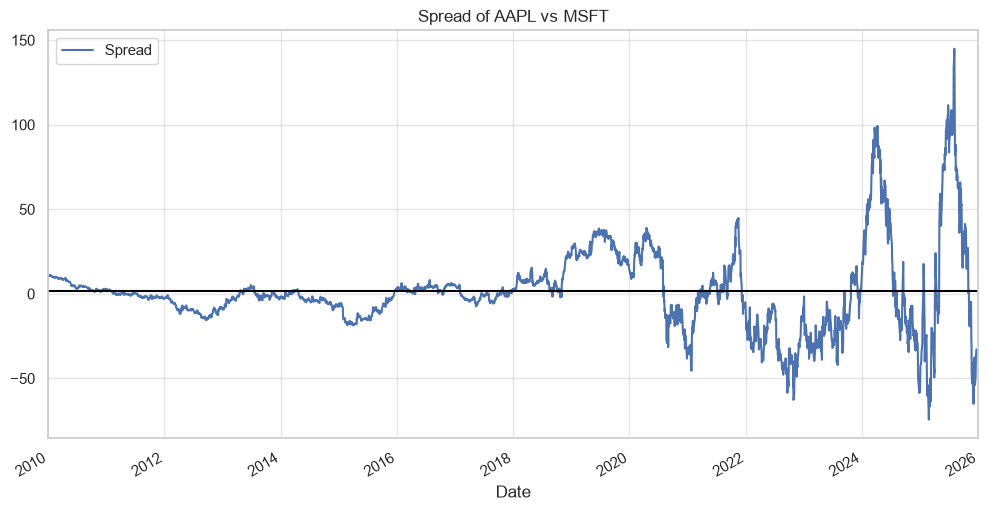

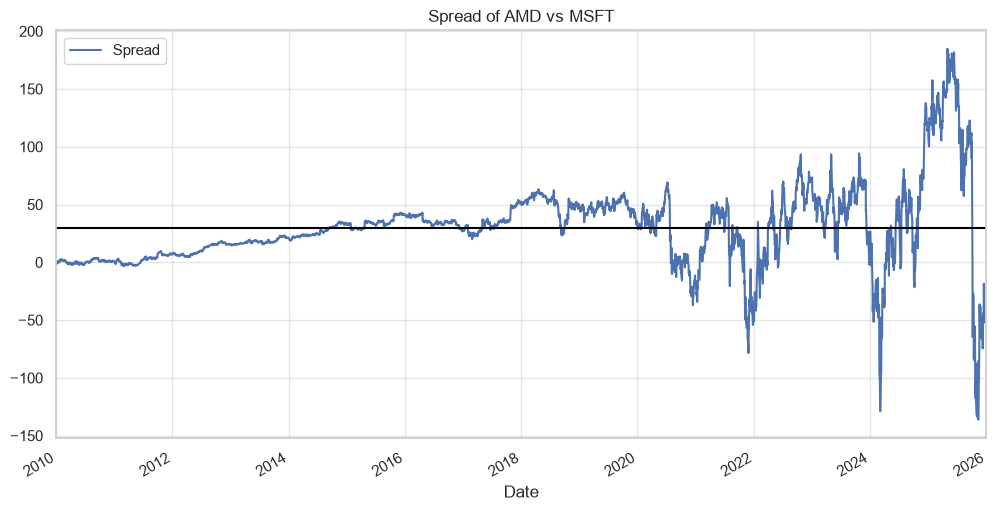

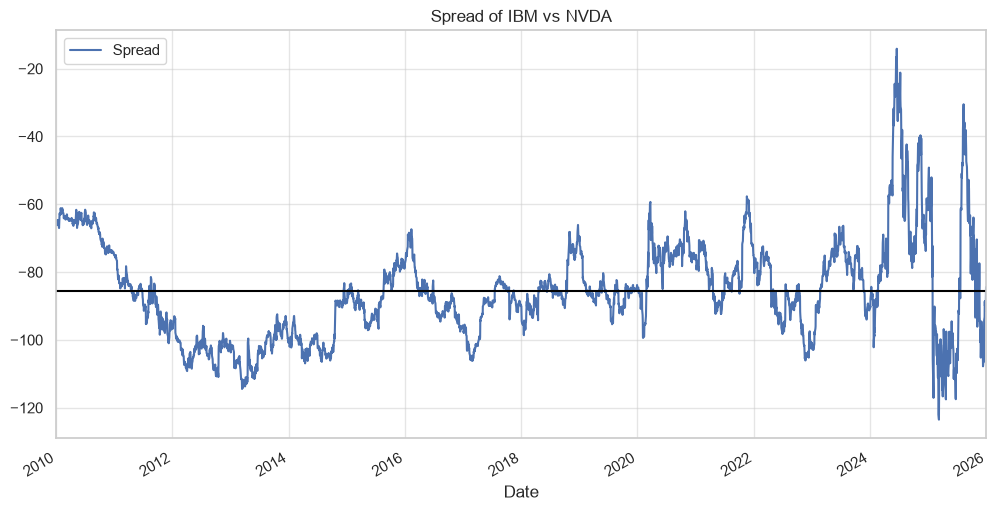

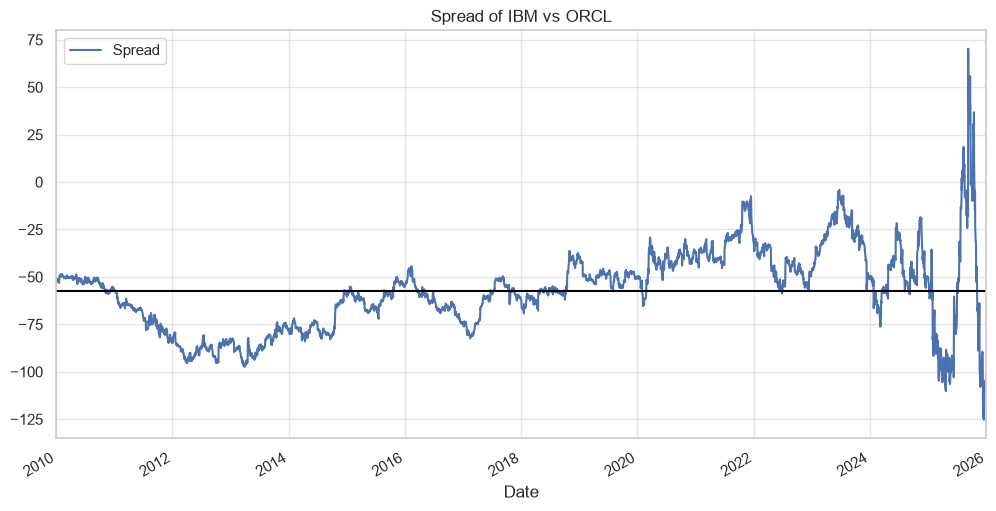

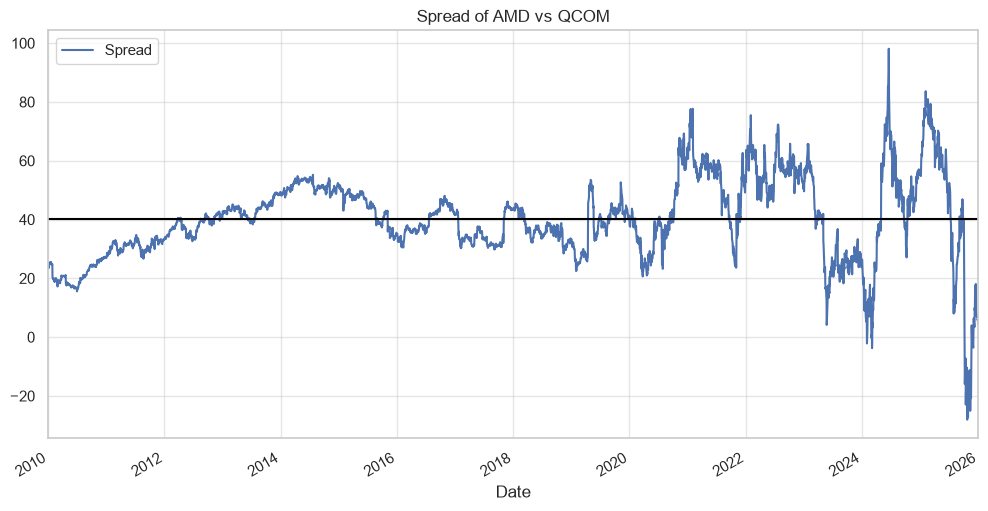

In [6]:
for i in range(0,len(ticker_1)):
    S1=df[ticker_1[i]]
    S2=df[ticker_2[i]]
    S1=sm.add_constant(S1)
    results = sm.OLS(S2, S1).fit()
    S1 = S1[ticker_1[i]]
    b = results.params[ticker_1[i]]

    spread = S2 - b * S1
    spread.plot(figsize=(12,6))
    plt.axhline(spread.mean(), color='black')
    plt.xlim(start,end)
    plt.title(f"Spread of {ticker_1[i]} vs {ticker_2[i]}")
    plt.legend(['Spread'])
    plt.show()

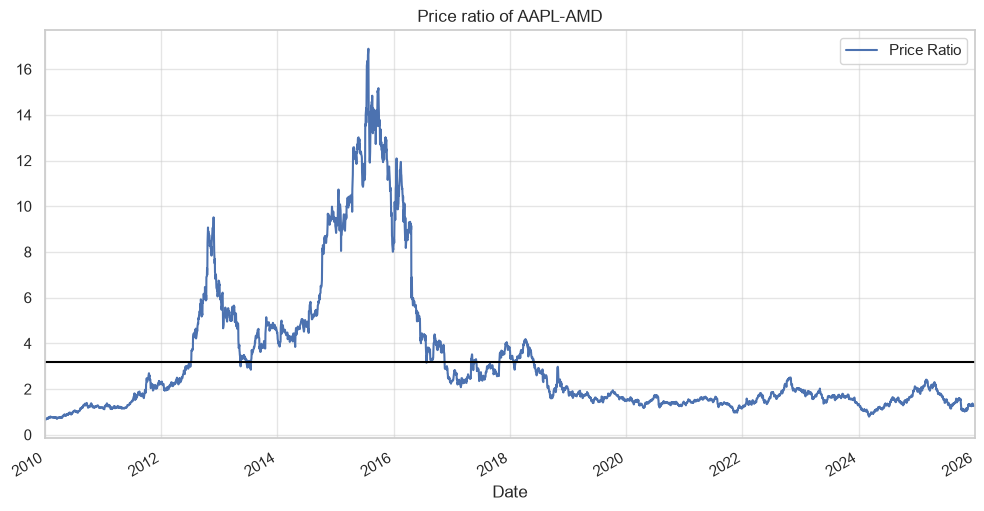

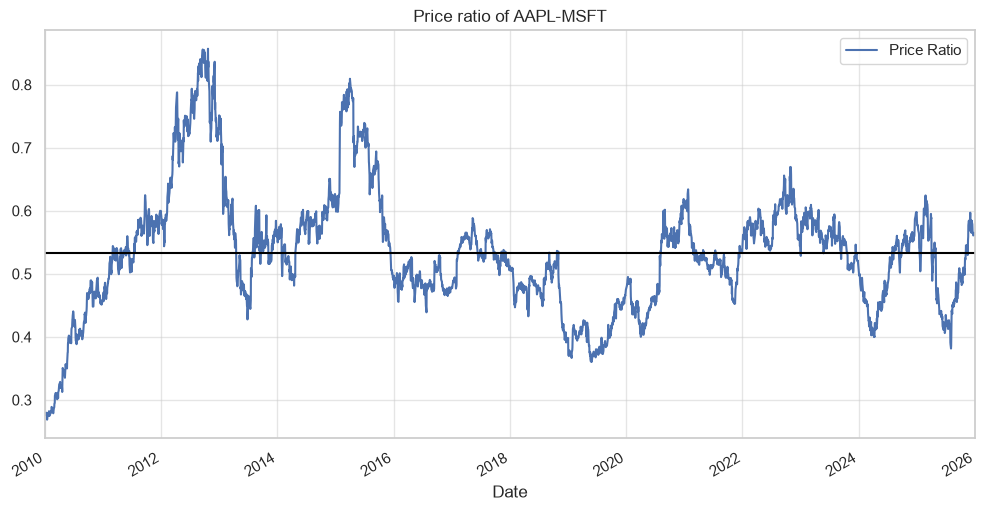

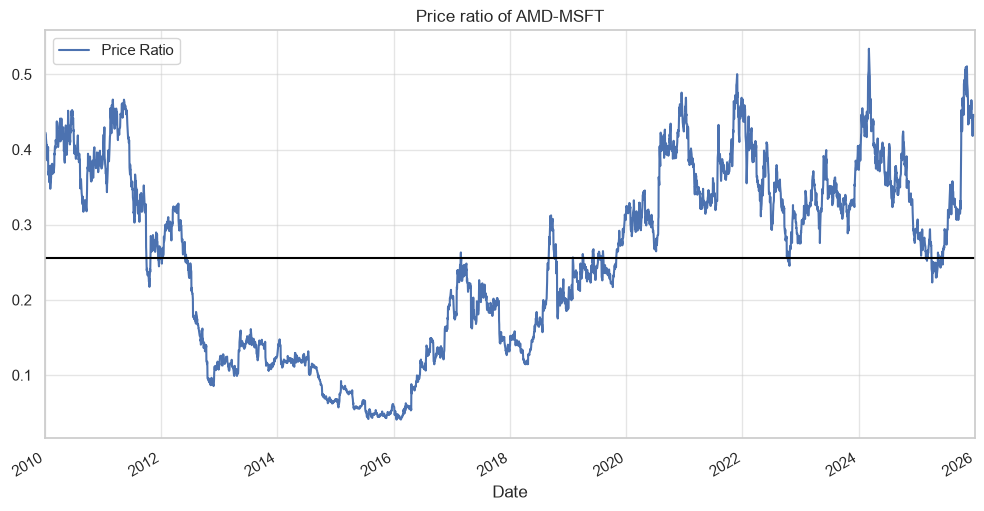

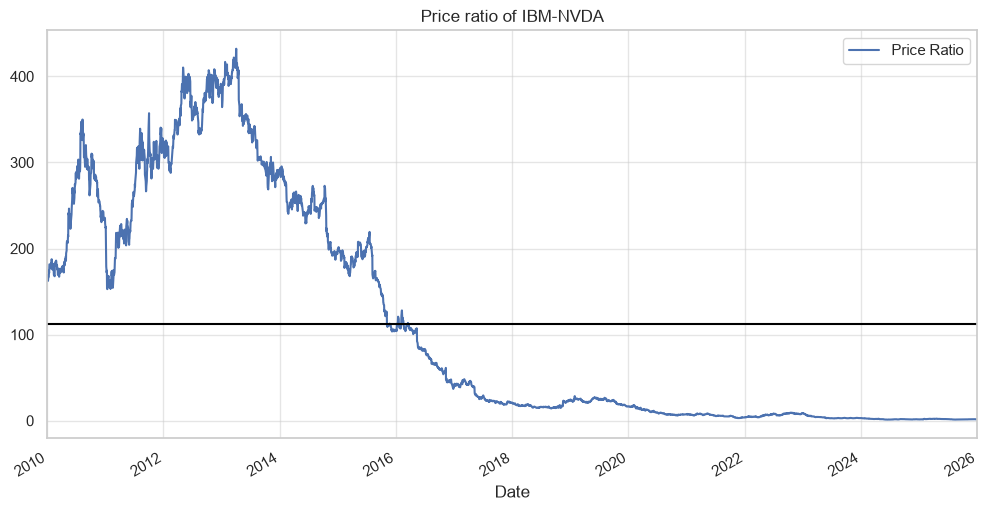

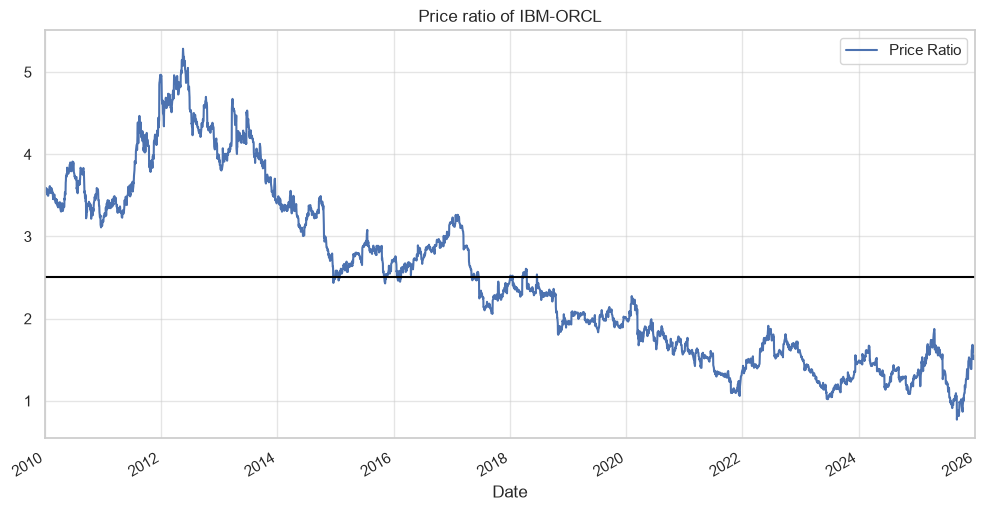

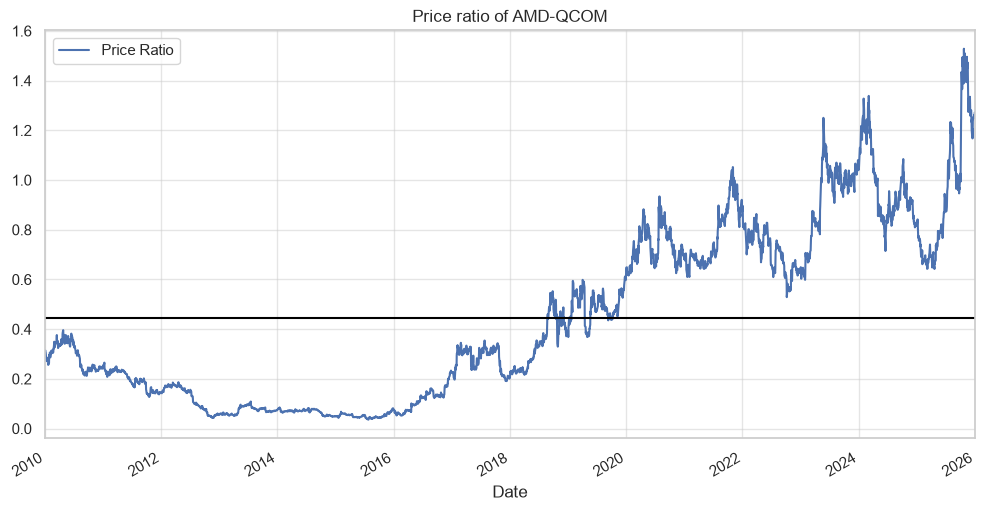

In [10]:
ratios={}
for i in range(0,len(ticker_1)):
    S1=df[ticker_1[i]]
    S2=df[ticker_2[i]]
    pair=f"{ticker_1[i]}-{ticker_2[i]}"
    ratios[pair] = S1/S2
    ratios[pair].plot(figsize=(12,6))
    plt.axhline(ratios[pair].mean(), color='black')
    plt.xlim(start, end)
    plt.title(f"Price ratio of {pair}")
    plt.legend(['Price Ratio'])
    plt.show()

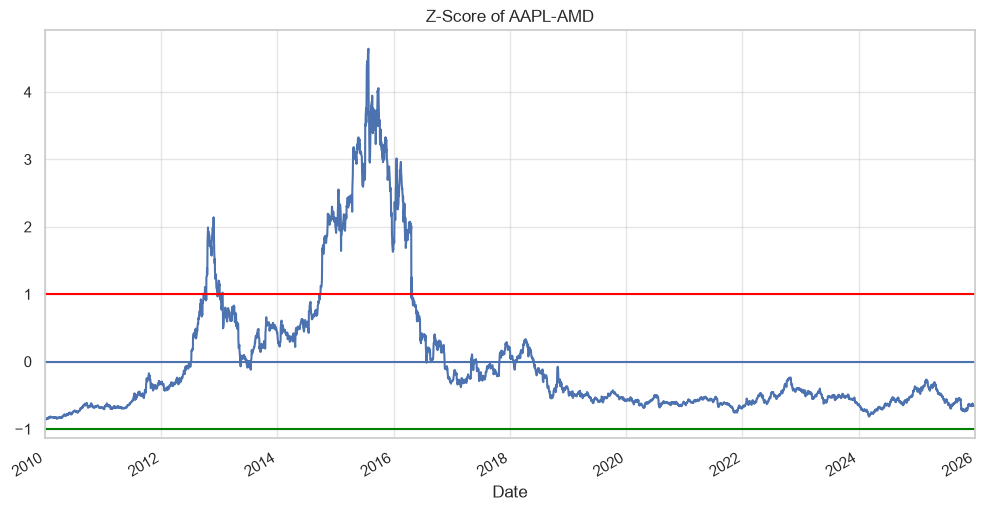

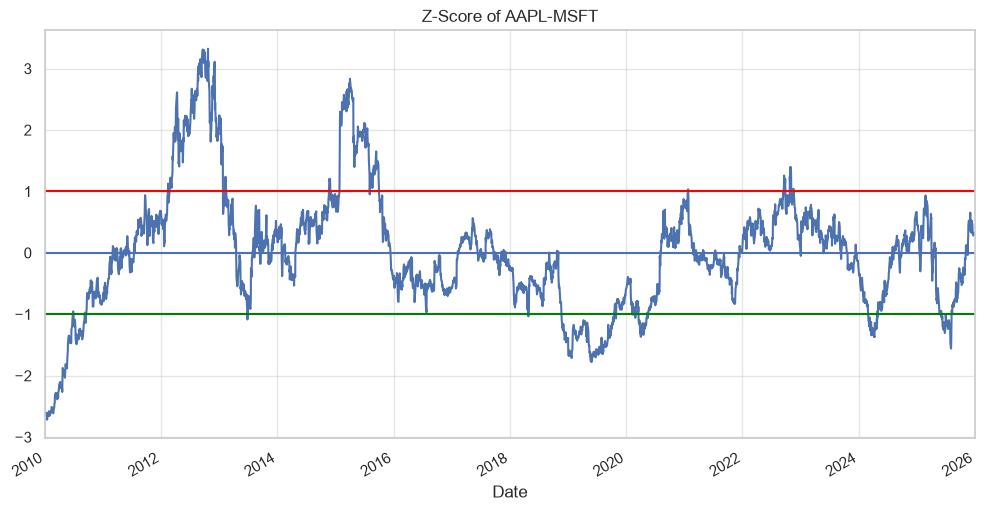

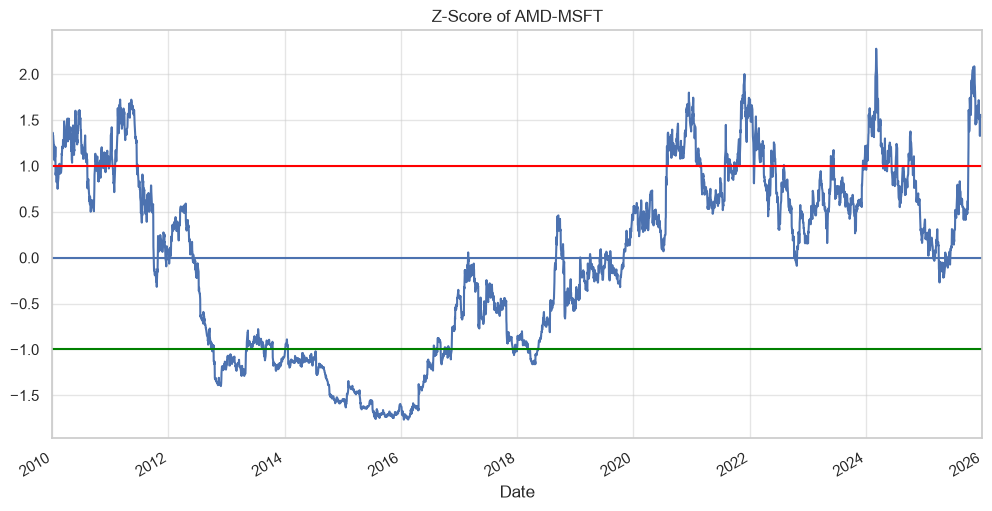

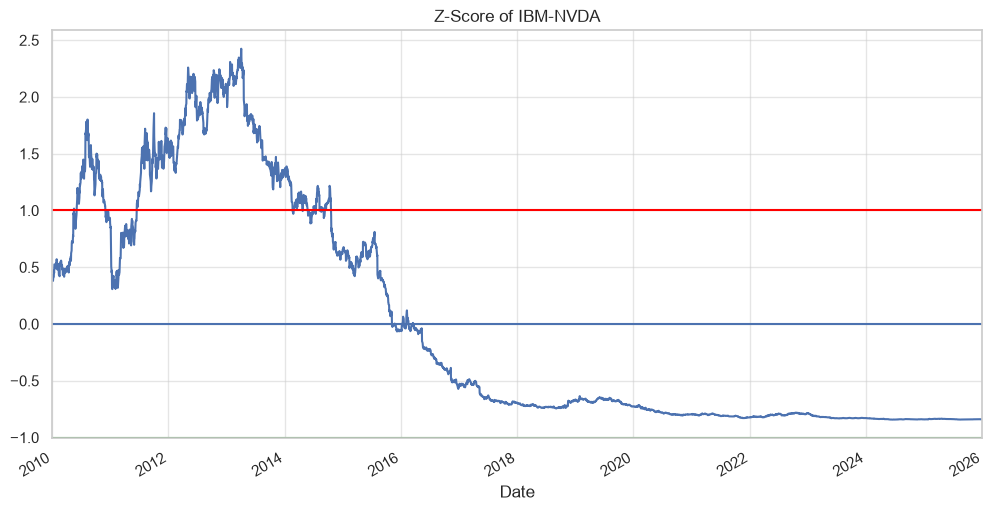

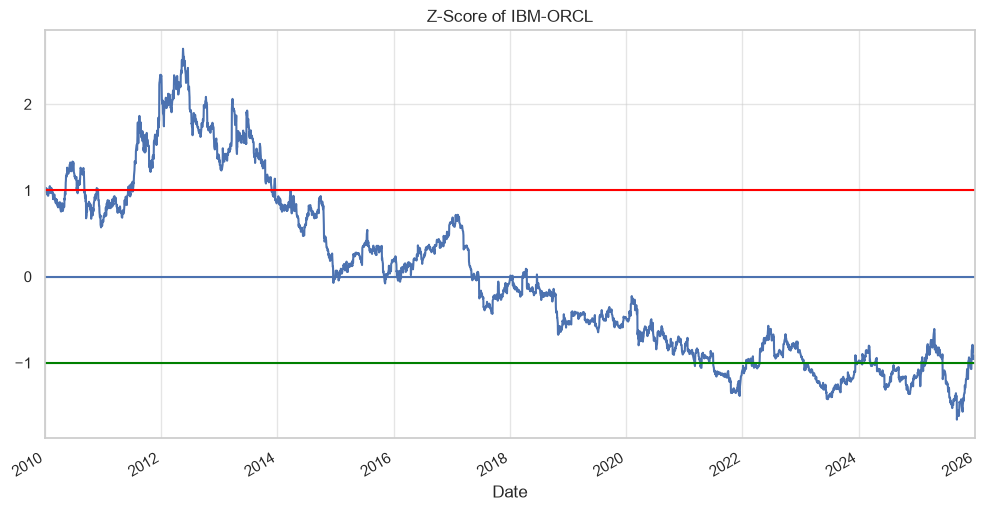

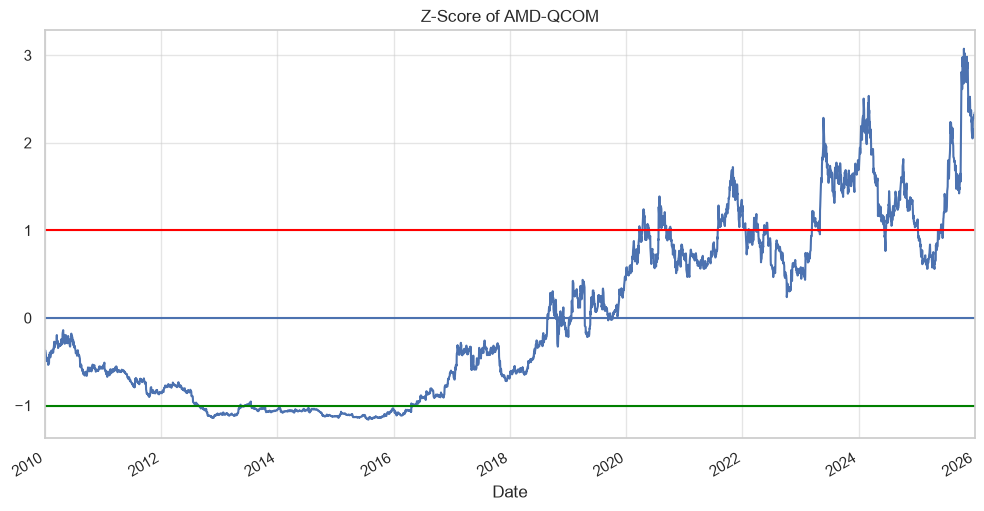

In [9]:
def zscore(series):
    return (series - series.mean()) / np.std(series)

for pair,ratio in ratios.items():
    zscore(ratio).plot(figsize=(12,6))
    plt.axhline(zscore(ratios[pair]).mean())
    plt.axhline(1.0, color='red')
    plt.axhline(-1.0, color='green')
    plt.xlim(start, end)
    plt.title(f"Z-Score of {pair}")
    plt.show()

In [13]:
train={}
test={}
split=int(len(df)*0.7)
for pair in ratios:
    train[pair]=ratios[pair].iloc[:split]
    test[pair]=ratios[pair].iloc[split:]

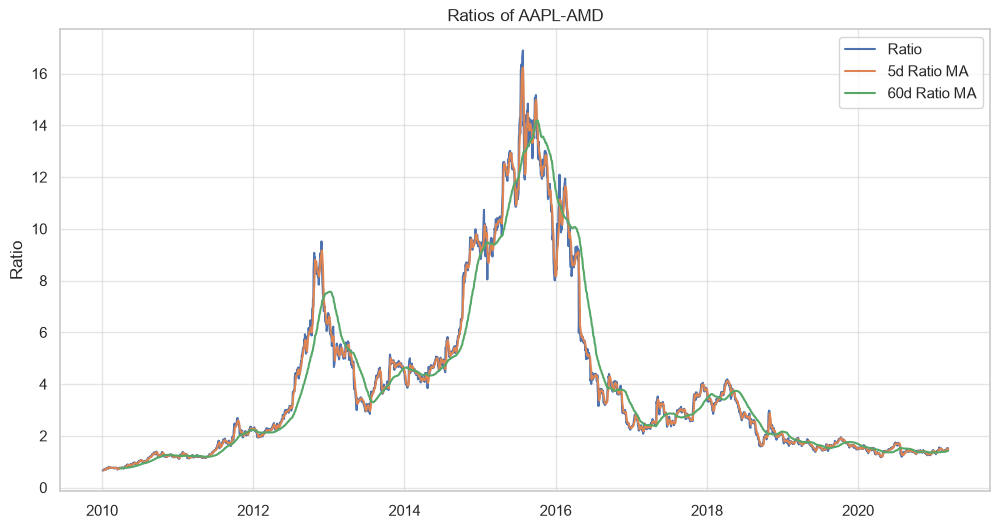

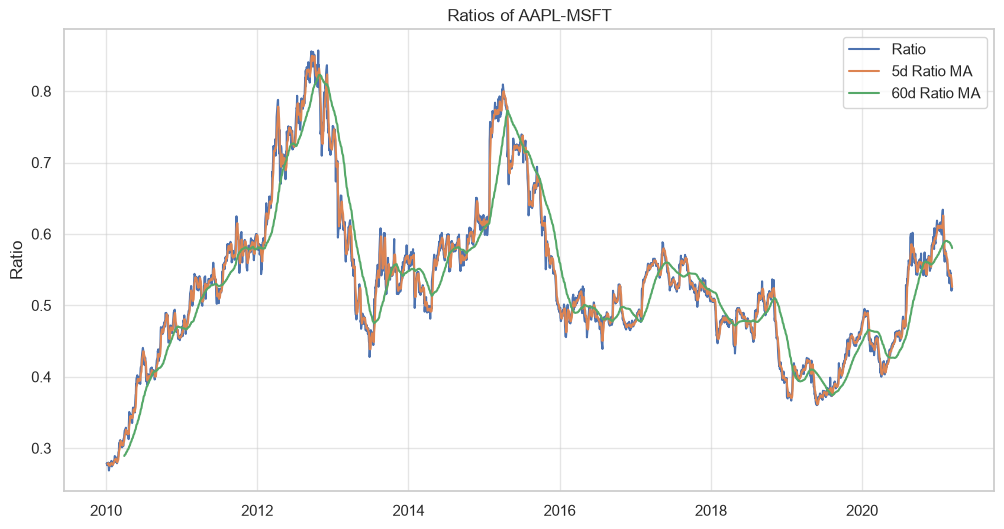

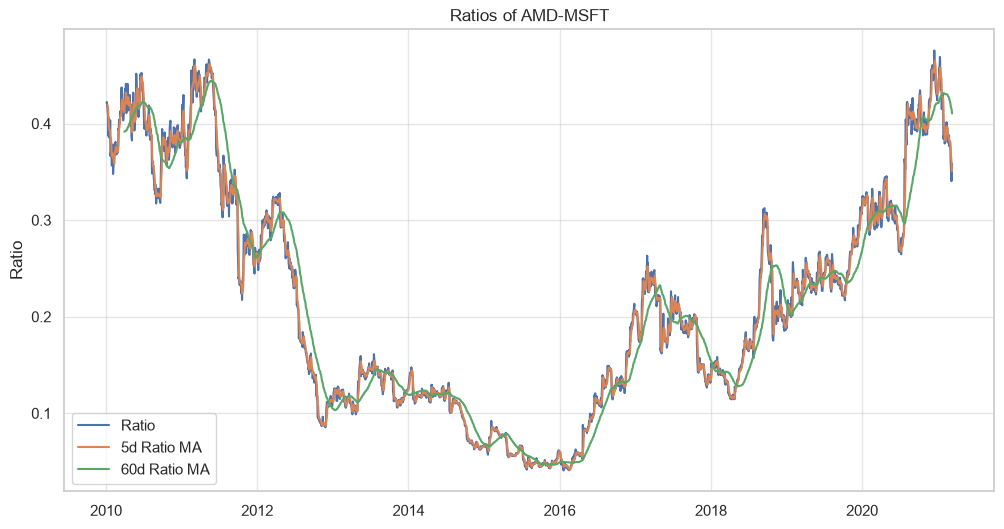

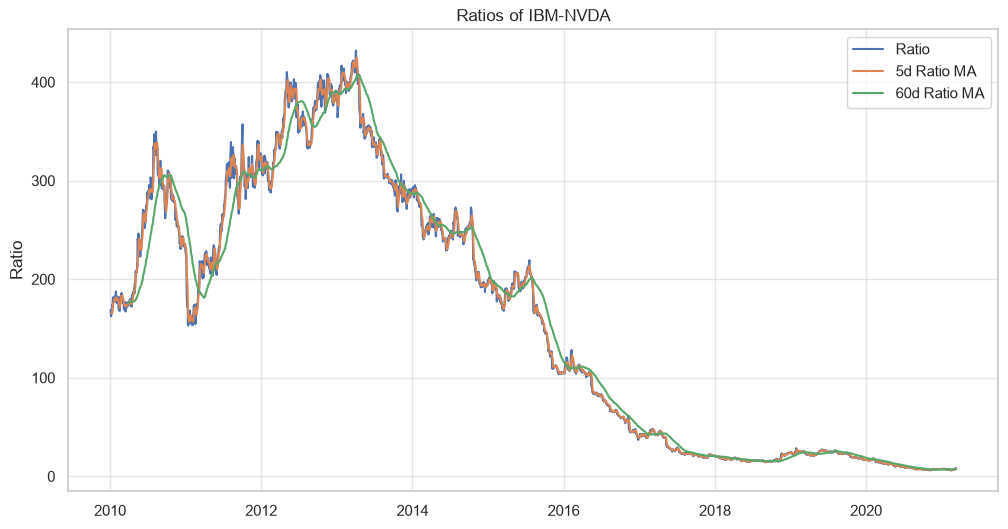

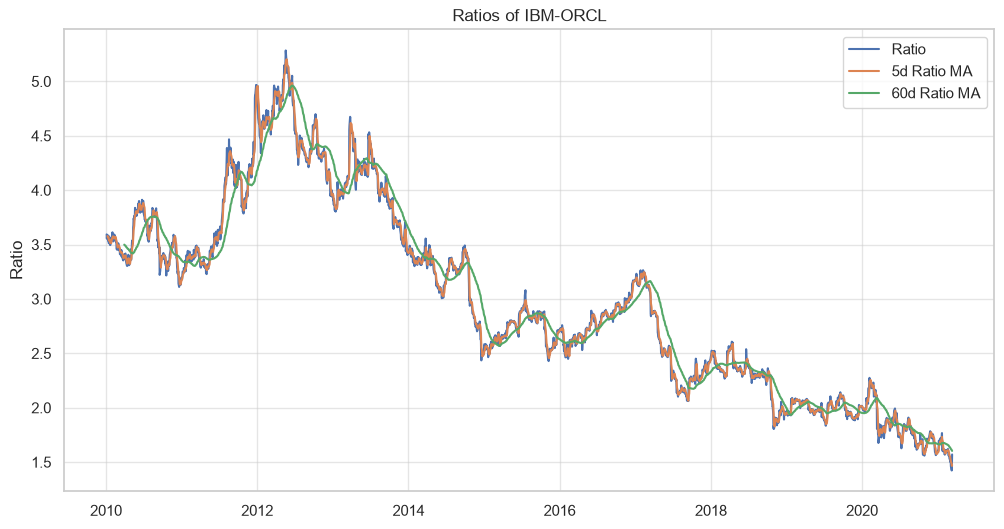

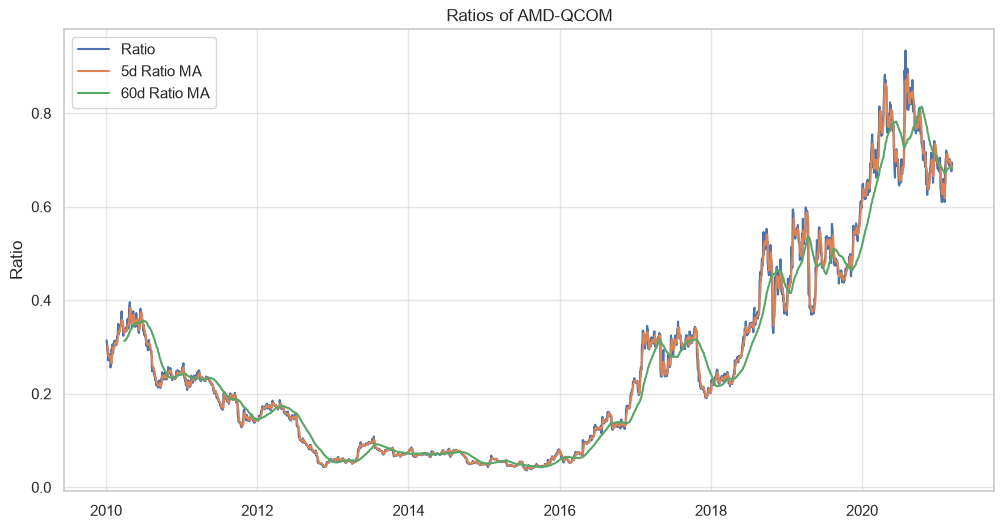

In [16]:
zscore_60_5={}
for pair in train:
    ratios_mavg5 = train[pair].rolling(window=5, center=False).mean()
    ratios_mavg60 = train[pair].rolling(window=60, center=False).mean()
    std_60 = train[pair].rolling(window=60, center=False).std()
    zscore_60_5[pair] = (ratios_mavg5 - ratios_mavg60)/std_60
    plt.figure(figsize=(12, 6))
    plt.plot(train[pair].index, train[pair].values)
    plt.plot(ratios_mavg5.index, ratios_mavg5.values)
    plt.plot(ratios_mavg60.index, ratios_mavg60.values)
    plt.legend(['Ratio', '5d Ratio MA', '60d Ratio MA'])
    plt.title(f"Ratios of {pair}")
    plt.ylabel('Ratio')
    plt.show()

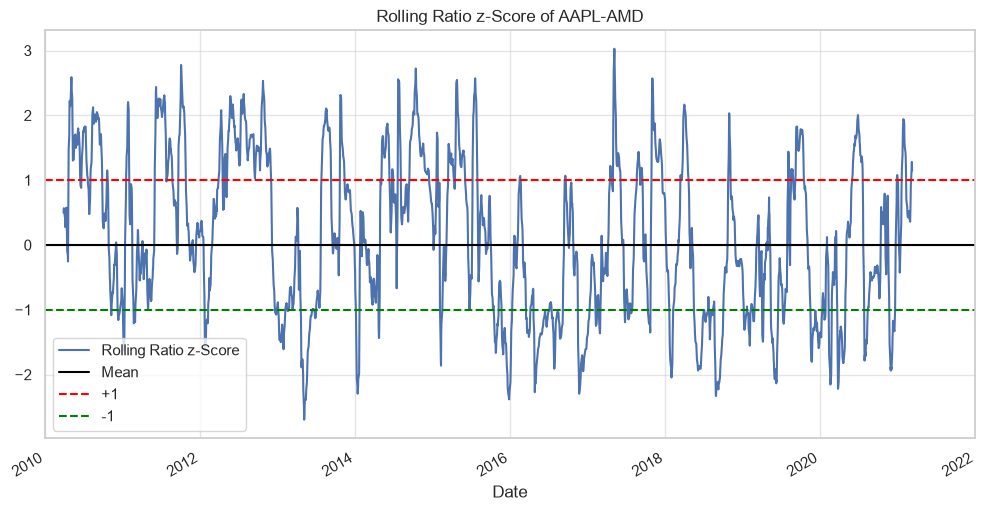

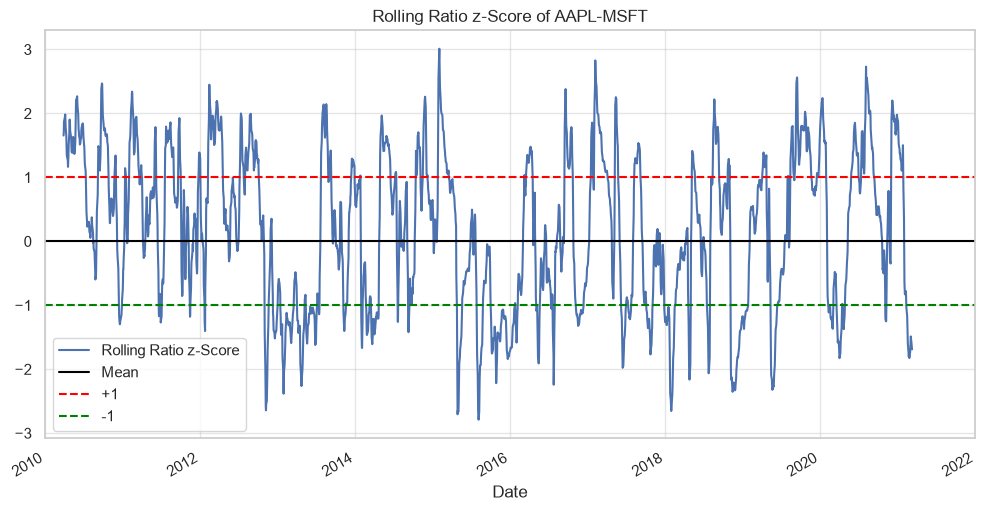

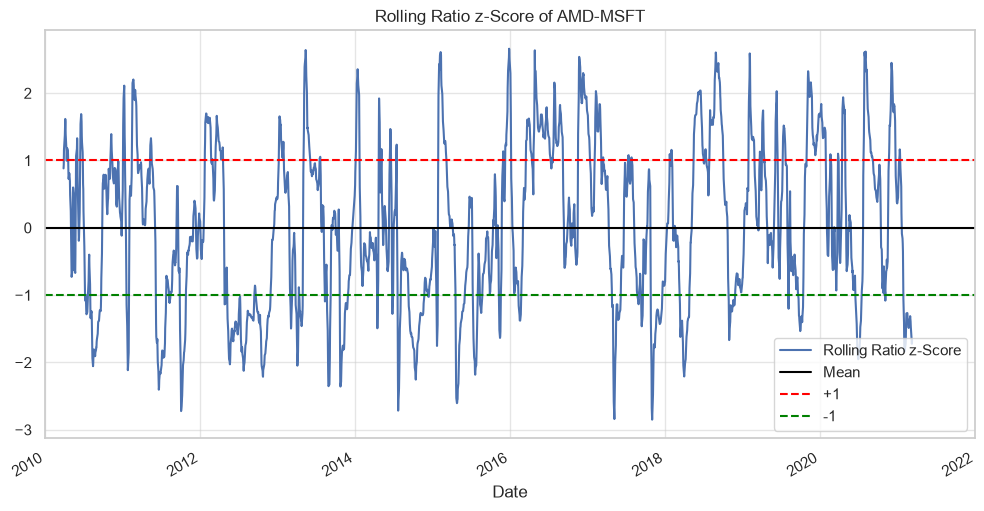

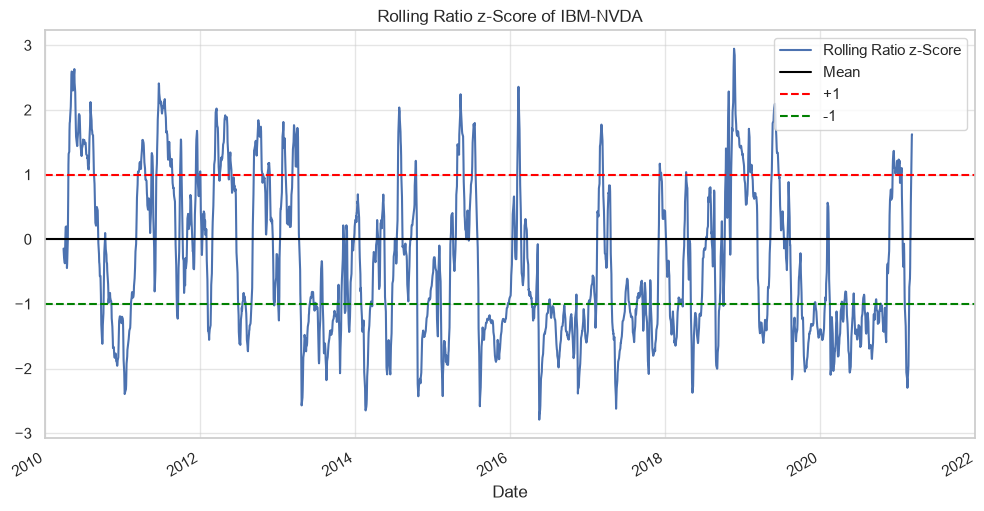

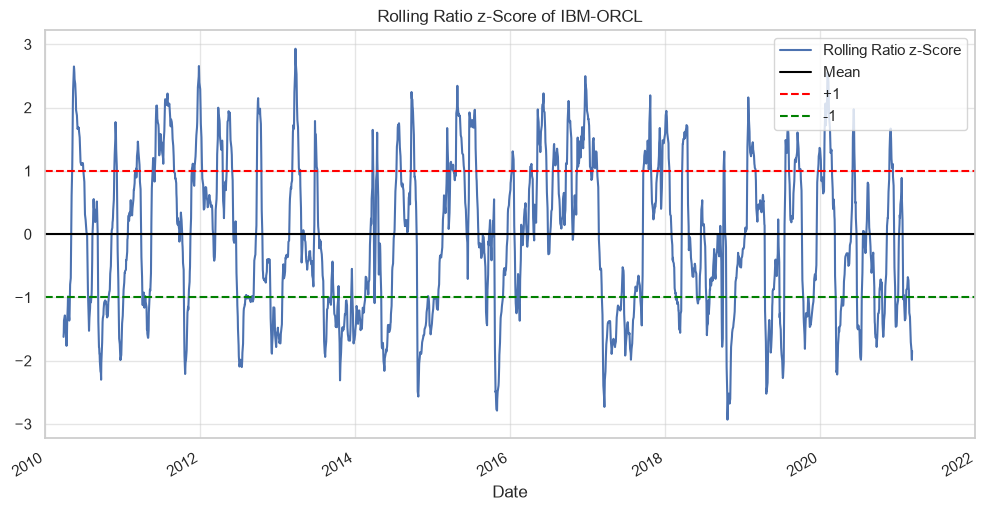

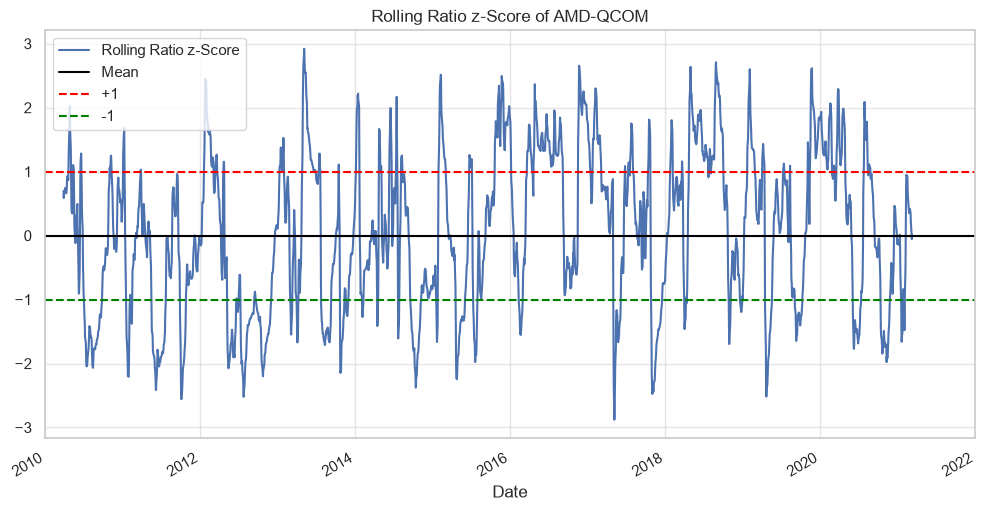

In [24]:
for pair in train:
    plt.figure(figsize=(12,6))
    zscore_60_5[pair].plot()
    plt.xlim(start,'2022,01,01')
    plt.axhline(0, color='black')
    plt.axhline(1.0, color='red', linestyle='--')
    plt.axhline(-1.0, color='green', linestyle='--')
    plt.legend(['Rolling Ratio z-Score', 'Mean', '+1', '-1'])
    plt.title(f"Rolling Ratio z-Score of {pair}")
    plt.show()

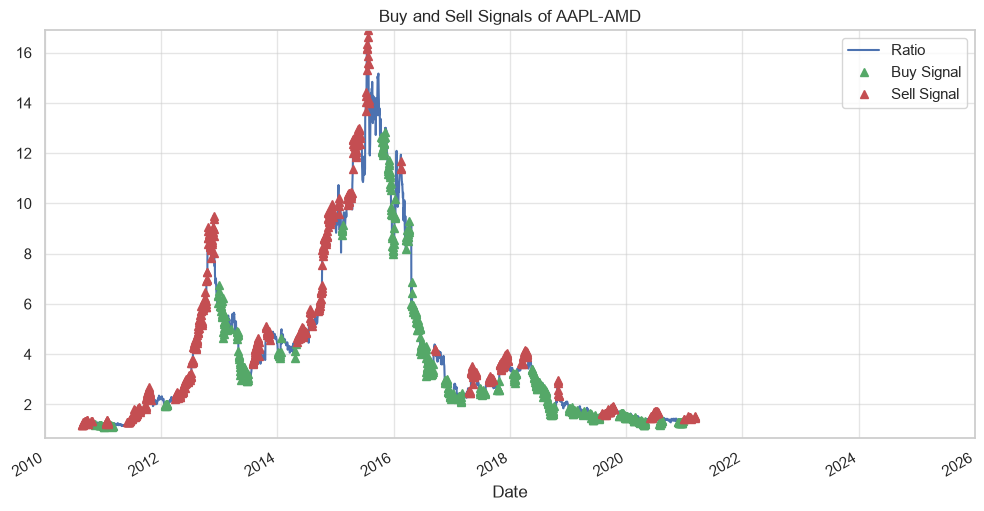

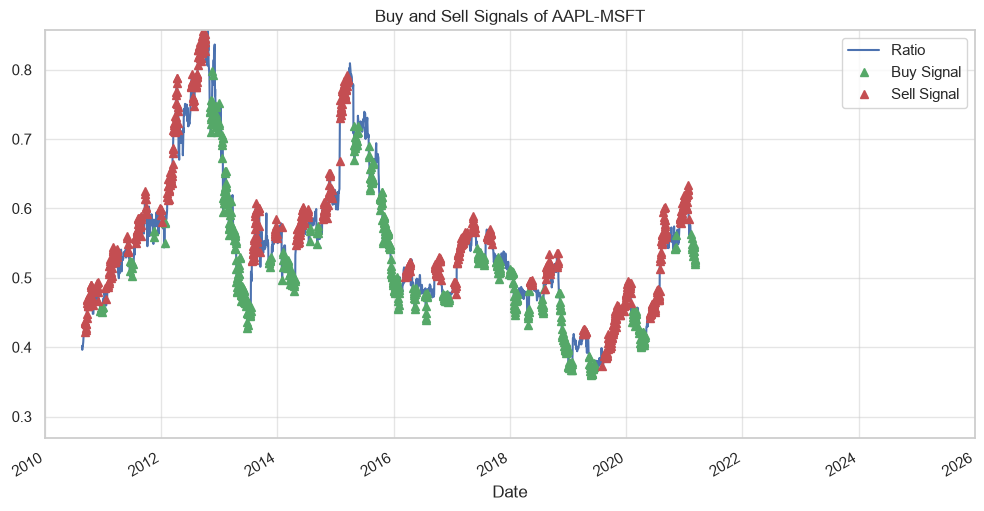

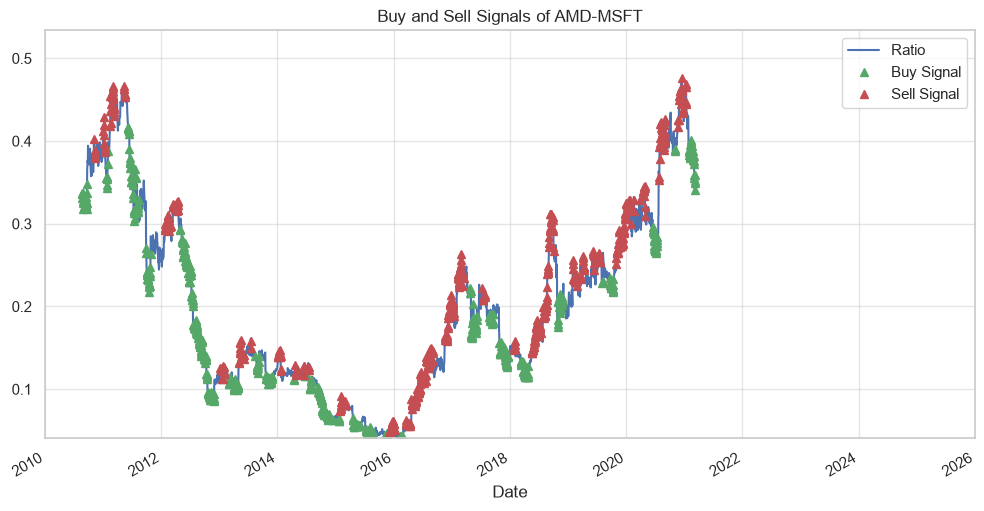

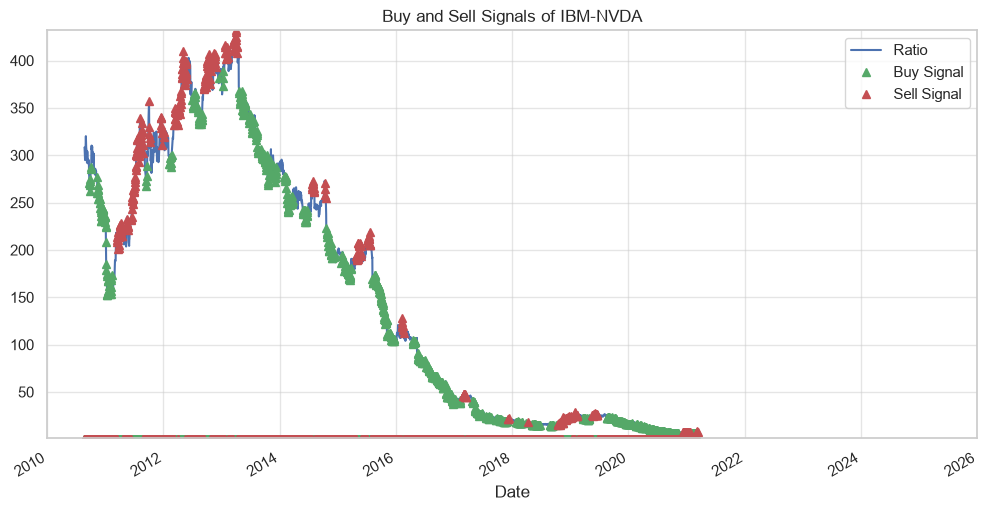

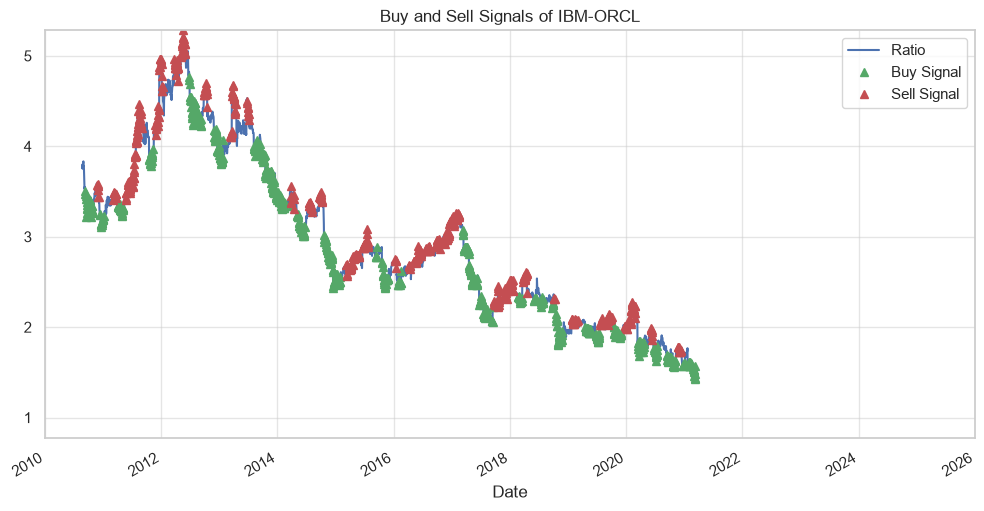

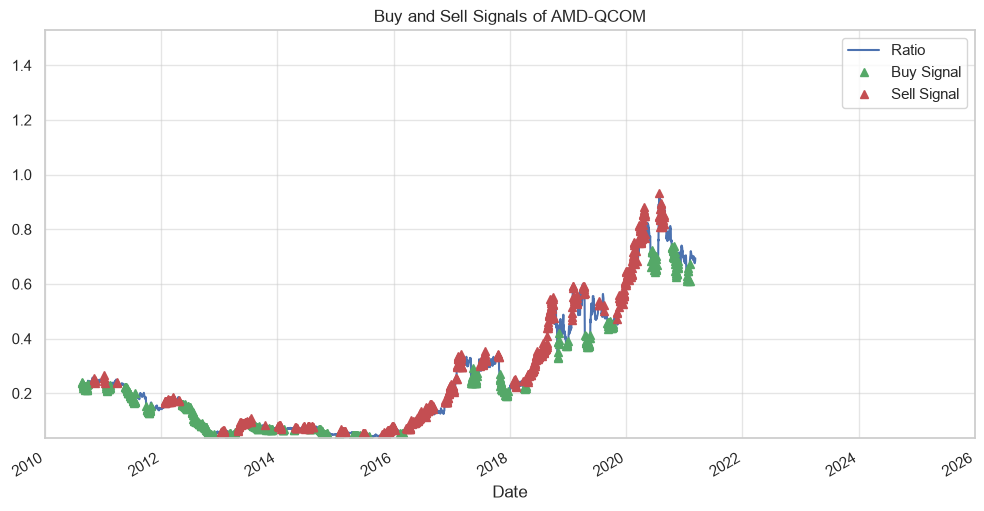

In [26]:
for pair in train:
    plt.figure(figsize=(12,6))
    train[pair][160:].plot()
    buy = train[pair].copy()
    sell = train[pair].copy()
    buy[zscore_60_5[pair]>-1] = 0
    sell[zscore_60_5[pair]<1] = 0
    buy[160:].plot(color='g', linestyle='None', marker='^')
    sell[160:].plot(color='r', linestyle='None', marker='^')
    x1, x2, y1, y2 = plt.axis()
    plt.axis((x1, x2, ratios[pair].min(), ratios[pair].max()))
    plt.xlim(start,end)
    plt.legend(['Ratio', 'Buy Signal', 'Sell Signal'])
    plt.title(f"Buy and Sell Signals of {pair}")
    plt.show()

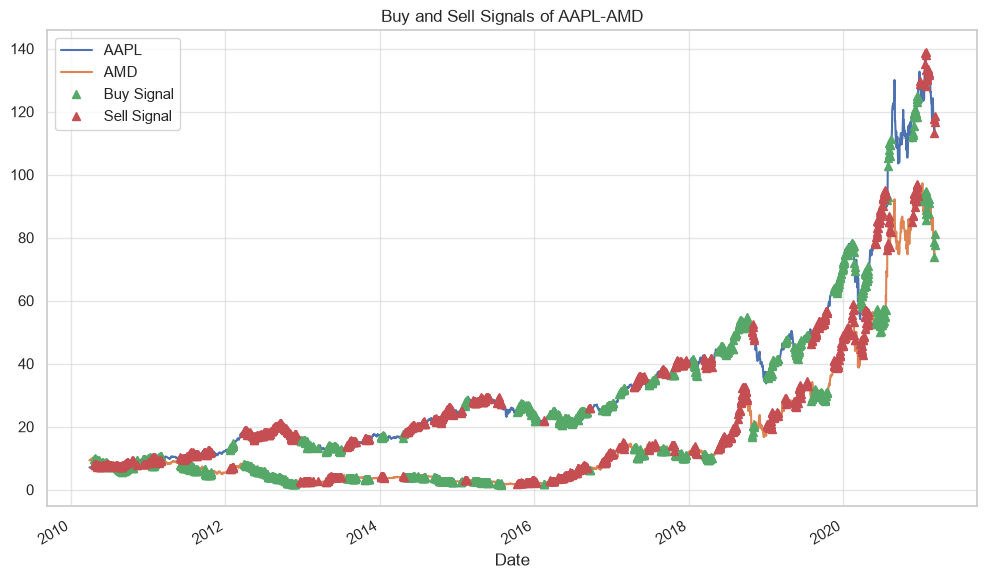

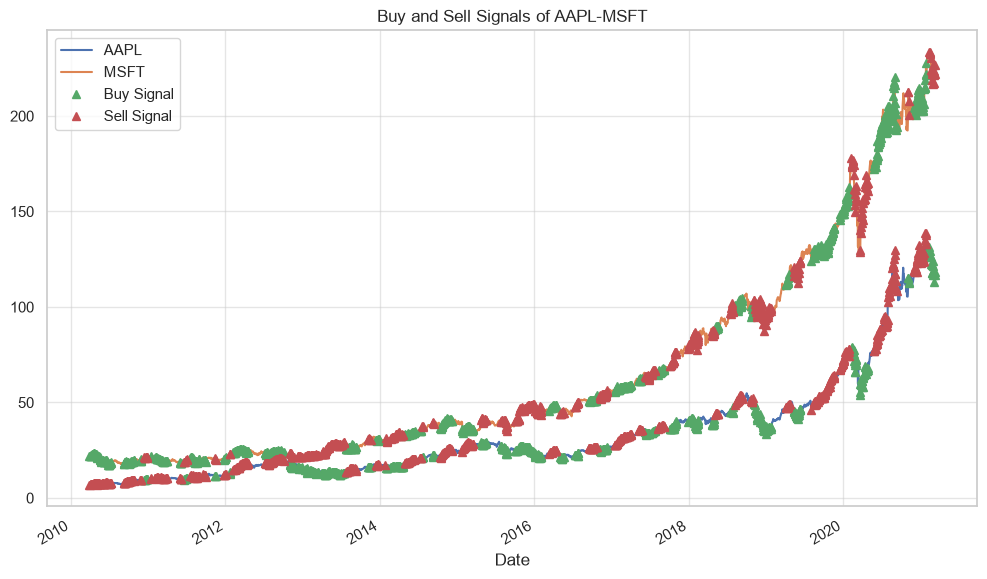

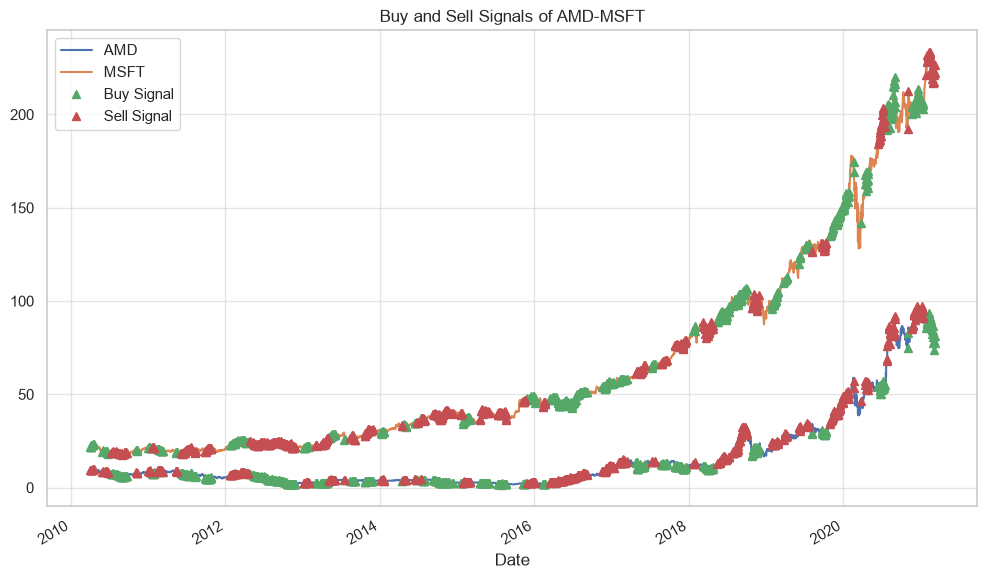

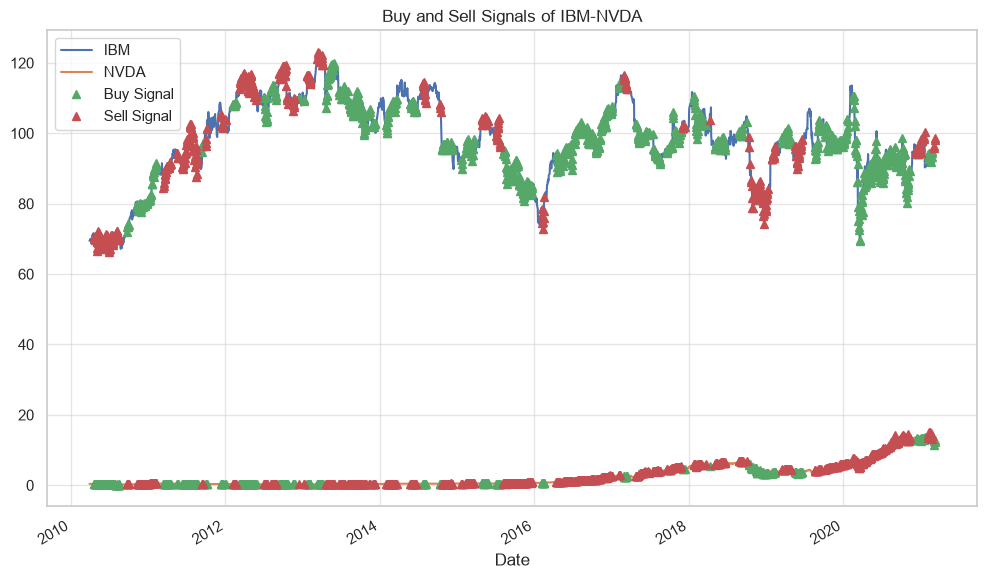

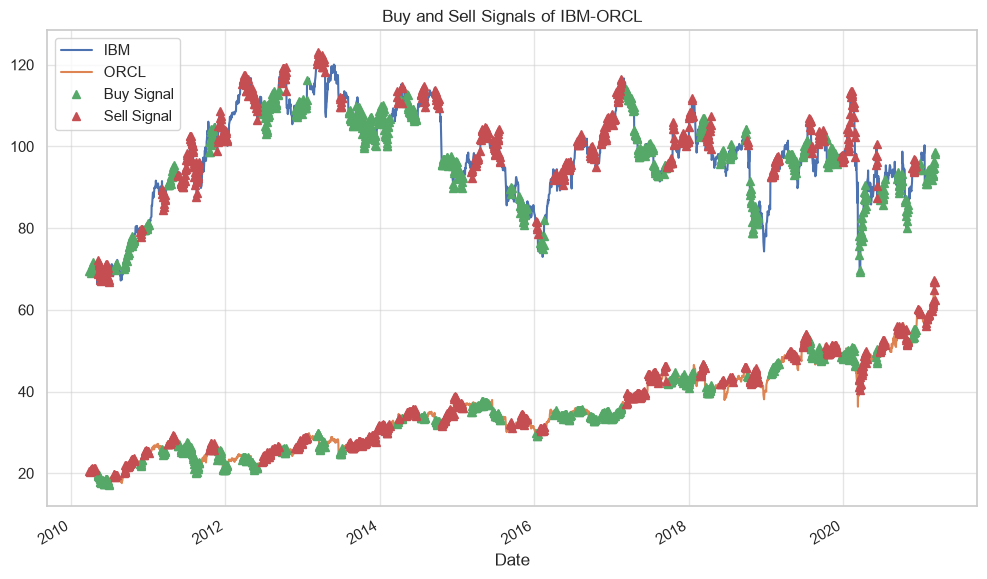

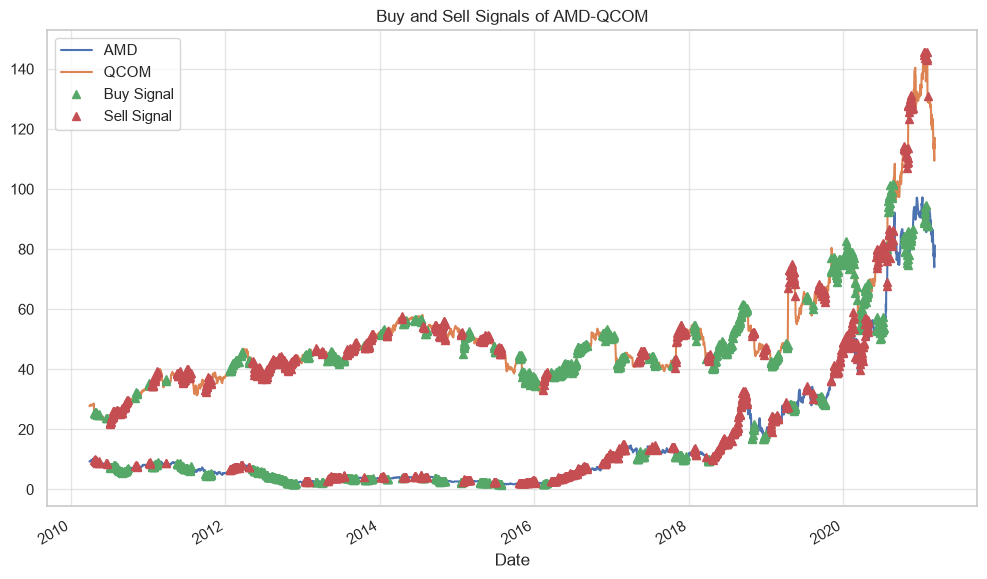

In [32]:
for pair in train:
    plt.figure(figsize=(12,7))
    ticker1, ticker2 = pair.split("-")
    S1 = df[ticker1].loc[train[pair].index]
    S2 = df[ticker2].loc[train[pair].index]
    buy = zscore_60_5[pair]<-1
    sell = zscore_60_5[pair]>1
    buyR = pd.Series(np.nan, index=train[pair].index)
    sellR = pd.Series(np.nan, index=train[pair].index)

    buyR[buy] = S1[buy]
    sellR[buy] = S2[buy]

    buyR[sell] = S2[sell]
    sellR[sell] = S1[sell]


    S1[60:].plot(label=ticker1)
    S2[60:].plot(label=ticker2)
    buyR[60:].plot(color='g', linestyle='None', marker='^')
    sellR[60:].plot(color='r', linestyle='None', marker='^')
    plt.title(f"Buy and Sell Signals of {pair}")
    plt.legend([ticker1, ticker2, 'Buy Signal', 'Sell Signal'])
    plt.show()

In [34]:
def trade(S1, S2, window1=60, window2=5):

    # If window length is 0, algorithm doesn't make sense, so exit
    if (window1 == 0) or (window2 == 0):
        return 0

    # Compute rolling mean and rolling standard deviation
    ratios = S1 / S2
    ma1 = ratios.rolling(window=window1, center=False).mean()
    ma2 = ratios.rolling(window=window2, center=False).mean()
    std = ratios.rolling(window=window2, center=False).std()
    zscore = (ma1 - ma2) / std

    # Simulate trading
    money = 0
    countS1 = 0
    countS2 = 0

    for i in range(len(ratios)):

        # Sell short if the z-score is > 1
        if zscore.iloc[i] < -1:
            money += S1.iloc[i] - S2.iloc[i] * ratios.iloc[i]
            countS1 -= 1
            countS2 += ratios.iloc[i]

        # Buy long if the z-score is < -1
        elif zscore.iloc[i] > 1:
            money -= S1.iloc[i] - S2.iloc[i] * ratios.iloc[i]
            countS1 += 1
            countS2 -= ratios.iloc[i]

        # Clear positions if the z-score is between -.75 and .75
        elif abs(zscore.iloc[i]) < 0.75:
            money += S1.iloc[i] * countS1 + S2.iloc[i] * countS2
            countS1 = 0
            countS2 = 0

    return money

In [35]:
for pair in train:
    ticker1, ticker2 = pair.split("-")
    print(f"Result of {pair} : ",trade(df[ticker1].loc[train[pair].index],df[ticker2].loc[train[pair].index]))

Result of AAPL-AMD :  34.461611434696934
Result of AAPL-MSFT :  45.54446120203397
Result of AMD-MSFT :  645.0084960515869
Result of IBM-NVDA :  -19475.83378194418
Result of IBM-ORCL :  1080.928943861606
Result of AMD-QCOM :  70.91407068930951
